## Trial 1 Analysis
Thursday, March 19

## Setup & Apparatus

We used a convection oven at 375 degrees Celsius to bake chips at a range of times. 85 chips were labelled and baked, then crushed the chips using a custom 3D printed attachment with a load cell to an Ender 3D printer moving at 5 mm/s.

<table><tr>
<td><img src="photos/Trial1_Setup_ConvectionOven.jpg" width="300"/><br><sub>Convection oven</sub></td>
<td><img src="photos/Trial1_Setup_Oven.jpg" width="300"/><br><sub>Oven interior</sub></td>
</tr><tr>
<td><img src="photos/Trial1_Setup_Printer.jpg" width="300"/><br><sub>Chip cutter / printer</sub></td>
<td><img src="photos/Trial1_Setup_UnbakedChips.jpg" width="300"/><br><sub>Unbaked chips</sub></td>
</tr></table>

## Data Collected

We labeled each chip individually and recorded initial and final masses. Then, using a modification of the Lab 1 MATLAB file, we used a 5kg load cell to measure the force. After that we ran a simple script that calculated the overall peak force detected, the first peak, and the impact energy (area under the curve) using trapz. (full script available in dataprocessing_trial1.m.) 
An image of a sample trial is below for visualization convenience of what our results generally looked like. .fig files in full are also in the trial 1 folder of this repo.

<td><img src="photos/Trial1_Results_MatlabSample.png" width="500"/><br><sub>Matlab for Chip 7 </sub></td>

#### 1.1 Pre-Analysis: Moisture loss v. baking time

We wanted to determine **moisture loss differs significantly between baking time groups**.

Moisture loss is defined here as the fractional mass lost during baking:

$$\text{Moisture loss} = \frac{m_\text{initial} - m_\text{final}}{m_\text{initial}}$$

Eight baking times were tested: **3, 3.5, 4, 4.5, 5.5, 6, 6.5, and 7 minutes** (note: no 5-minute group in this trial).

#### 1.2. Method

A **two-sample independent t-test** asks: given the means and variability of two groups, how likely is it that the observed difference in means occurred by chance if the groups were actually drawn from the same population? With 8 groups, there are $\binom{8}{2} = 28$ pairwise comparisons. Running 28 independent tests at a significance threshold of $\alpha = 0.05$ means we'd expect $28 \times 0.05 = 1.4$ false positives even if no groups actually differed. We therefore report both:
- **Raw p-value**: the unadjusted test result
- **Bonferroni-corrected p-value**: the raw p-value multiplied by 28 (the number of tests), capped at 1.0. A corrected p-value < 0.05 gives stronger evidence of a true difference.

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

#### 1.2 Load & Clean Data

In [114]:
df = pd.read_csv('fracture_energy_trial1.csv')

# Drop empty trailing rows
df = df.dropna(subset=['Bake time (min)', 'Moisture loss'])
df = df.rename(columns={
    'Bake time (min)': 'Bake_time',
    'Moisture loss':   'Moisture_loss',
})

# Convert moisture loss to percentage for readability
df['Moisture_loss_pct'] = df['Moisture_loss'] * 100

# Sort by bake time
df = df.sort_values('Bake_time').reset_index(drop=True)

bake_times = sorted(df['Bake_time'].unique())
print(f"Chips loaded: {len(df)}")
print(f"Bake times: {bake_times}")
df[['Trial', 'Bake_time', 'Initial mass (g)', 'Final mass (g)', 'dmass (g)', 'Moisture_loss_pct', 'FractureEnergy_J']].head(10)

Chips loaded: 74
Bake times: [np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.5), np.float64(6.0), np.float64(6.5), np.float64(7.0)]


,Trial,Bake_time,Initial mass (g),Final mass (g),dmass (g),Moisture_loss_pct,FractureEnergy_J
0,61.0,3.0,2.4,1.6,0.8,33.333333,0.014781
1,62.0,3.0,2.2,1.5,0.7,31.818182,0.022265
2,63.0,3.0,2.8,1.9,0.9,32.142857,0.012240
3,64.0,3.0,3.0,2.0,1.0,33.333333,0.055119
4,68.0,3.0,2.8,2.1,0.7,25.000000,0.034087
5,67.0,3.0,3.1,2.4,0.7,22.580645,0.025735
6,66.0,3.0,3.2,2.3,0.9,28.125000,0.046129
7,65.0,3.0,2.9,2.1,0.8,27.586207,0.042518
8,70.0,3.0,3.0,2.1,0.9,30.000000,0.047615
9,69.0,3.0,3.0,2.1,0.9,30.000000,0.015212


#### 1.3 Per-Group Summary Statistics

Before running any tests, we characterise each bake time group individually. For each group we report:

| Statistic | Symbol | Meaning |
|---|---|---|
| **n** | $n$ | Number of chips tested |
| **Mean** | $\bar{x}$ | Average moisture loss (%) |
| **SD** | $s$ | Standard deviation — spread of individual chips around the mean |
| **SE** | $s/\sqrt{n}$ | Standard error — uncertainty in the *mean* itself; smaller with more chips |
| **95% CI** | $\bar{x} \pm t_{0.025,\,n-1} \cdot SE$ | Range within which the true mean lies with 95% confidence |
| **Min / Max** | — | Full observed range |

A large SD relative to the difference between two group means is a warning sign that t-tests may not find significance — the signal is buried in noise.

In [115]:
rows = []
for bt in bake_times:
    grp = df.loc[df['Bake_time'] == bt, 'Moisture_loss_pct']
    n   = len(grp)
    mu  = grp.mean()
    sd  = grp.std(ddof=1)
    se  = sd / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)  # two-tailed 95%
    ci_lo  = mu - t_crit * se
    ci_hi  = mu + t_crit * se
    rows.append({
        'Bake time (min)': bt,
        'n': n,
        'Mean (%)': round(mu, 2),
        'SD (%)':   round(sd, 2),
        'SE (%)':   round(se, 3),
        '95% CI lower': round(ci_lo, 2),
        '95% CI upper': round(ci_hi, 2),
        'Min (%)':  round(grp.min() * 1, 2),
        'Max (%)':  round(grp.max() * 1, 2),
    })

summary = pd.DataFrame(rows).set_index('Bake time (min)')
summary

,n,Mean (%),SD (%),SE (%),95% CI lower,95% CI upper,Min (%),Max (%)
Bake time (min),,,,,,,,
3.0,10,29.39,3.59,1.134,26.83,31.96,22.58,33.33
3.5,10,25.66,5.23,1.655,21.91,29.40,16.67,34.48
4.0,4,29.51,3.15,1.574,24.50,34.51,25.00,32.26
4.5,10,32.31,2.99,0.945,30.18,34.45,27.59,37.04
5.5,10,34.05,2.88,0.910,31.99,36.11,30.00,39.29
6.0,10,33.17,4.59,1.452,29.88,36.45,26.92,41.38
6.5,10,31.41,5.12,1.619,27.75,35.07,22.22,37.50
7.0,10,32.88,4.80,1.519,29.44,36.32,25.00,39.29


**Comments**: The SD column tells you how variable moisture loss is within a bake time group. If two groups have means that are close together relative to their SDs, a t-test is unlikely to find a significant difference there is  too much overlap. The 95% CI columns show the plausible range for each group's true mean; overlapping CIs are a strong visual signal that a t-test will not be significant.

#### 1.4 Visualisation

C:\Users\shere\AppData\Local\Temp\ipykernel_9632\3801576670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y='Moisture_loss_pct',


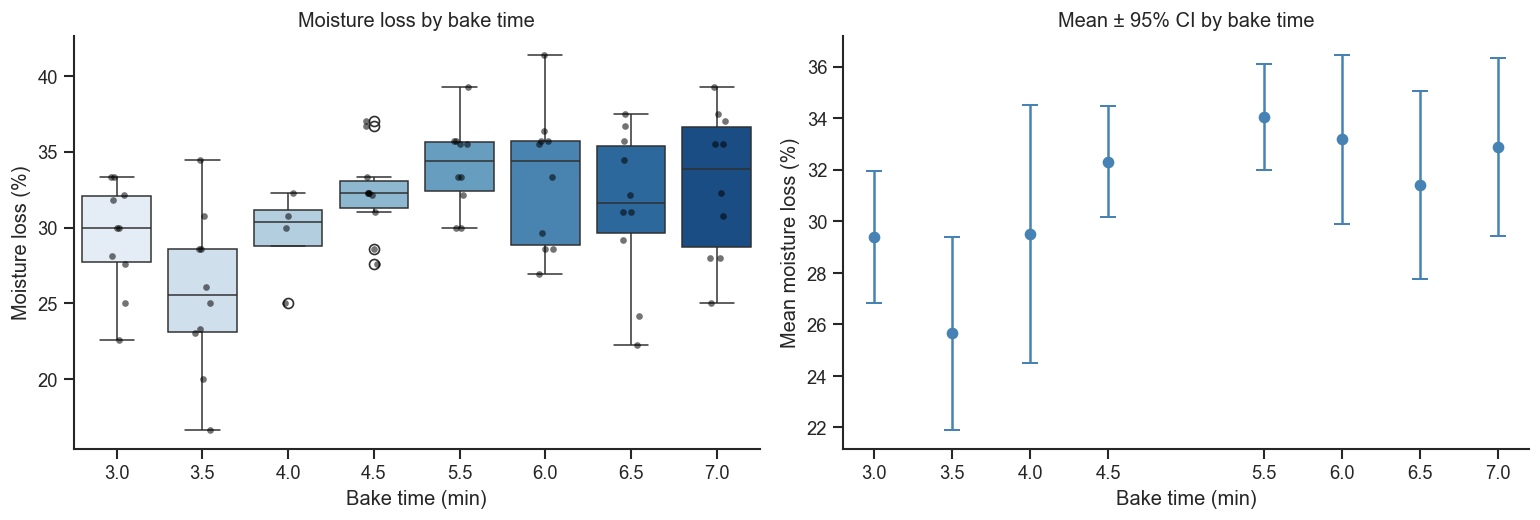

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: box + strip plot ---
ax = axes[0]
sns.boxplot(data=df, x='Bake_time', y='Moisture_loss_pct',
            palette='Blues', linewidth=0.9, ax=ax, order=bake_times)
sns.stripplot(data=df, x='Bake_time', y='Moisture_loss_pct',
              color='black', alpha=0.55, size=4, jitter=True,
              ax=ax, order=bake_times)
ax.set_xlabel('Bake time (min)')
ax.set_ylabel('Moisture loss (%)')
ax.set_title('Moisture loss by bake time')

# --- Right: mean ± 95% CI ---
ax2 = axes[1]
for bt in bake_times:
    row = summary.loc[bt]
    ax2.errorbar(bt, row['Mean (%)'],
                 yerr=[[row['Mean (%)'] - row['95% CI lower']],
                       [row['95% CI upper'] - row['Mean (%)']]],
                 fmt='o', capsize=5, capthick=1.2, markersize=6,
                 color='steelblue', ecolor='steelblue')
ax2.set_xlabel('Bake time (min)')
ax2.set_ylabel('Mean moisture loss (%)')
ax2.set_title('Mean ± 95% CI by bake time')
ax2.set_xticks(bake_times)

sns.despine()
plt.tight_layout()
plt.show()

### Results: Baked Chips with Punctures
The following image is an example of what a punctured set of chips looks like. \n
<img src="photos/Trial1_Results_BakedChips.jfif" width="200"/>

**Comments**: The box plot (left) shows the full distribution of moisture loss within each group the box spans the interquartile range (25th-75th percentile), the horizontal line inside is the median, and the whiskers extend to 1.5x— the IQR. The mean ± 95% CI plot (right) is more useful for comparing groups: if two confidence intervals do not overlap, the groups are very likely to be statistically significantly different. Overlapping CIs do not guarantee non-significance, but wide overlaps suggest the groups are hard to distinguish.

#### 1.5 Pairwise t-Tests

We use Welch's t-test, which does not assume the two groups have equal variance appropriate here since some groups may be more variable than others.

The t-statistic is then converted to a p-value using a t-distribution.  A large |t| (far from zero) corresponds to a small p-value.

#### Multiple comparisons correction

With 28 tests at $\alpha = 0.05$, the expected number of false positives is $28 \times 0.05 = 1.4$. The Bonferroni correction addresses this by requiring a raw p-value below $0.05 / 28 \approx 0.00179$ to claim significance. Equivalently, the corrected p-value (raw alpha, 28, capped at 1.0) must be below 0.05.

In [117]:
pairs = list(combinations(bake_times, 2))
n_tests = len(pairs)
alpha = 0.05

results = []
for bt_a, bt_b in pairs:
    a = df.loc[df['Bake_time'] == bt_a, 'Moisture_loss_pct'].dropna().values
    b = df.loc[df['Bake_time'] == bt_b, 'Moisture_loss_pct'].dropna().values
    t_stat, p_raw = stats.ttest_ind(a, b, equal_var=False)  # Welch's
    p_bonf = min(p_raw * n_tests, 1.0)
    mean_diff = a.mean() - b.mean()
    results.append({
        'Group A (min)':   bt_a,
        'Group B (min)':   bt_b,
        'Mean A (%)':      round(a.mean(), 2),
        'Mean B (%)':      round(b.mean(), 2),
        'Diff A-B (%)':    round(mean_diff, 2),
        'SD A (%)':        round(a.std(ddof=1), 2),
        'SD B (%)':        round(b.std(ddof=1), 2),
        'n_A':             len(a),
        'n_B':             len(b),
        't-stat':          round(t_stat, 3),
        'p (raw)':         round(p_raw, 4),
        'p (Bonf)':        round(p_bonf, 4),
        'Sig (raw)':       '✓' if p_raw < alpha else '',
        'Sig (Bonf)':      '✓' if p_bonf < alpha else '',
    })

results_df = pd.DataFrame(results)
print(f"Total comparisons: {n_tests}  |  Bonferroni threshold: p < {alpha/n_tests:.5f}")
results_df

Total comparisons: 28  |  Bonferroni threshold: p < 0.00179


,Group A (min),Group B (min),Mean A (%),Mean B (%),Diff A-B (%),SD A (%),SD B (%),n_A,n_B,t-stat,p (raw),p (Bonf),Sig (raw),Sig (Bonf)
0,3.0,3.5,29.39,25.66,3.74,3.59,5.23,10,10,1.862,0.0812,1.0000,,
1,3.0,4.0,29.39,29.51,-0.11,3.59,3.15,10,4,-0.059,0.9546,1.0000,,
2,3.0,4.5,29.39,32.31,-2.92,3.59,2.99,10,10,-1.980,0.0637,1.0000,,
3,3.0,5.5,29.39,34.05,-4.66,3.59,2.88,10,10,-3.202,0.0052,0.1446,✓,
4,3.0,6.0,29.39,33.17,-3.78,3.59,4.59,10,10,-2.049,0.0562,1.0000,,
5,3.0,6.5,29.39,31.41,-2.02,3.59,5.12,10,10,-1.021,0.3223,1.0000,,
6,3.0,7.0,29.39,32.88,-3.49,3.59,4.80,10,10,-1.840,0.0836,1.0000,,
7,3.5,4.0,25.66,29.51,-3.85,5.23,3.15,10,4,-1.686,0.1244,1.0000,,
8,3.5,4.5,25.66,32.31,-6.66,5.23,2.99,10,10,-3.494,0.0035,0.0973,✓,
9,3.5,5.5,25.66,34.05,-8.39,5.23,2.88,10,10,-4.444,0.0006,0.0156,✓,✓


#### 1.6 Summary of Significant Differences

In [118]:
sig_raw  = results_df[results_df['Sig (raw)']  == '✓']
sig_bonf = results_df[results_df['Sig (Bonf)'] == '✓']

print(f"Significant (raw p < 0.05):          {len(sig_raw)} / {n_tests} comparisons")
print(f"Significant (Bonferroni-corrected):  {len(sig_bonf)} / {n_tests} comparisons")
print()
if len(sig_bonf) > 0:
    print("Pairs that survive Bonferroni correction:")
    print(sig_bonf[['Group A (min)', 'Group B (min)', 'Mean A (%)', 'Mean B (%)',
                     'Diff A-B (%)', 't-stat', 'p (raw)', 'p (Bonf)']].to_string(index=False))
else:
    print("No pairs survive Bonferroni correction.")

Significant (raw p < 0.05):          6 / 28 comparisons
Significant (Bonferroni-corrected):  1 / 28 comparisons

Pairs that survive Bonferroni correction:
 Group A (min)  Group B (min)  Mean A (%)  Mean B (%)  Diff A-B (%)  t-stat  p (raw)  p (Bonf)
           3.5            5.5       25.66       34.05         -8.39  -4.444   0.0006    0.0156


#### 1.7 Heatmap of p-values

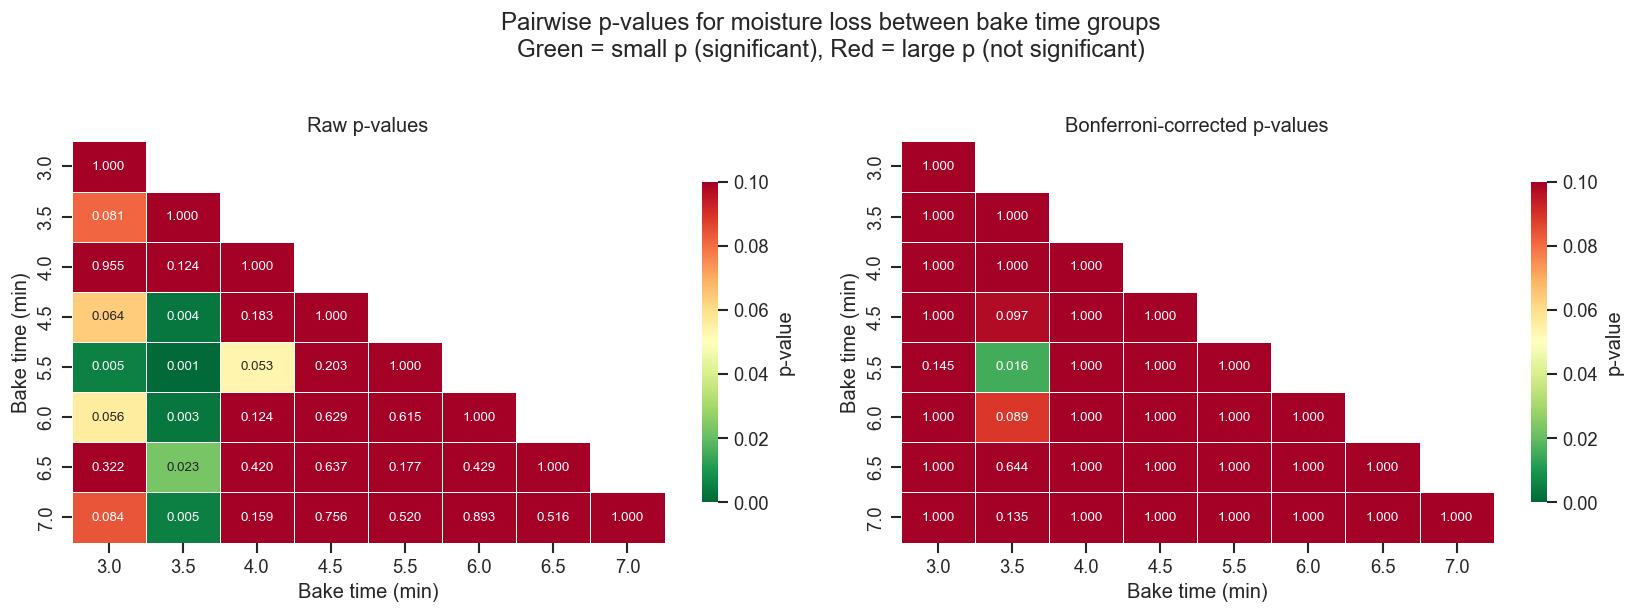

In [119]:
# Build a symmetric matrix of Bonferroni-corrected p-values
bt_labels = [str(bt) for bt in bake_times]
p_matrix = pd.DataFrame(np.nan, index=bt_labels, columns=bt_labels)
for _, row in results_df.iterrows():
    a, b = str(row['Group A (min)']), str(row['Group B (min)'])
    p_matrix.loc[a, b] = row['p (Bonf)']
    p_matrix.loc[b, a] = row['p (Bonf)']
np.fill_diagonal(p_matrix.values, 1.0)  # self-comparisons

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (p_col, title) in zip(axes, [
    ('p (raw)',  'Raw p-values'),
    ('p (Bonf)', 'Bonferroni-corrected p-values'),
]):
    mat = pd.DataFrame(np.nan, index=bt_labels, columns=bt_labels)
    for _, row in results_df.iterrows():
        a, b = str(row['Group A (min)']), str(row['Group B (min)'])
        mat.loc[a, b] = row[p_col]
        mat.loc[b, a] = row[p_col]
    np.fill_diagonal(mat.values, 1.0)

    # Mask the upper triangle
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, mask=mask, annot=True, fmt='.3f',
                cmap='RdYlGn_r', vmin=0, vmax=0.1,
                linewidths=0.5, ax=ax, annot_kws={'size': 8},
                cbar_kws={'label': 'p-value', 'shrink': 0.8})
    ax.set_title(title)
    ax.set_xlabel('Bake time (min)')
    ax.set_ylabel('Bake time (min)')

plt.suptitle('Pairwise p-values for moisture loss between bake time groups\n'
             'Green = small p (significant), Red = large p (not significant)', y=1.02)
plt.tight_layout()
plt.show()

**Notes**: Each cell shows the p-value for the comparison between two bake times. Green cells indicate small p-values (strong evidence of a difference); red cells indicate large p-values (little evidence). The threshold for significance (0.05) sits in the yellow-green range. The right panel applies Bonferroni correction.

#### 1.8 Conclusions

Within-group variability in moisture loss is large relative to between-group differences. Each bake time group shows a standard deviation of roughly 3-6 percentage points, while the differences in group means across the full 3-7 minute range span only about 5-10 percentage points. This low signal-to-noise ratio is the main reason the t-tests may fail to find significance even for groups that appear to differ. The data are insufficient to rule out chance as an explanation for the observed difference. With n = 10 chips per group, the tests have limited statistical power. To reliably detect a 5 percentage-point difference with this level of variability, roughly 15-20 chips per group would be needed.

---

## Part 2: Fracture Mechanics Analysis

#### 2.1 The Puffing Problem

With moisture loss characterised in Part 1, we turn to the mechanical measurements collected during each fracture test: first-peak force (F_peak), maximum force (F_max), and fracture energy (E_f, area under the force–displacement curve). Each chip was fractured at a single point in the centre.

### 2.1 The puffing problem

A key confound in Trial 1 is chip puffing. Chips baked at higher temperatures and longer times often developed internal steam pockets, causing the chip surface to dome or bubble. When a puffed chip is placed on the ring fixture, the punch contacts the raised bubble rather than the flat chip body. The first-peak force (F_peak) reflects the collapse of the bubble, not the fracture of the chip matrix. This makes the displacement at first peak highly variable, making F_peak an unreliable proxy for fracture toughness.

The following image is an example of what a punctured set of chips looks like.

<img src="photos/Trial1_Results_BakedChips.jpg" width="600"/>

This phenomenon was made more severe by the variance in puffing between batches; low-time batches tended not to experience as much puffing. 
F_max and E_f are less directly corrupted (the chip does eventually fracture) but still suffer from the inconsistent loading geometry introduced by puffing.

### 2.2 Derived fracture quantities

From the raw test data we compute several material properties.

| Quantity | Symbol | Definition |
|---|---|---|
| Fracture energy density | $G_c$ (J/m²) | Raw energy divided by punch cross-section area |
| Biaxial fracture stress | $\sigma_c$ (MPa) | Peak force scaled by a geometry factor from thin-plate theory |
| Elastic modulus | $E$ (MPa) | Stiffness from force–displacement slope and plate dimensions |
| Fracture toughness | $K_{Ic}$ (Pa√m) | $\sqrt{G_c \cdot E}$ — combines energy release and stiffness |

$\sigma_c$, $E$, and $K_{Ic}$ assume small deflections and linear elasticity — treat them as order-of-magnitude estimates. All derived quantities scale with apparatus geometry (R, r, t) and Poisson's ratio ν = 0.3; the same formulae are applied identically in both trials.

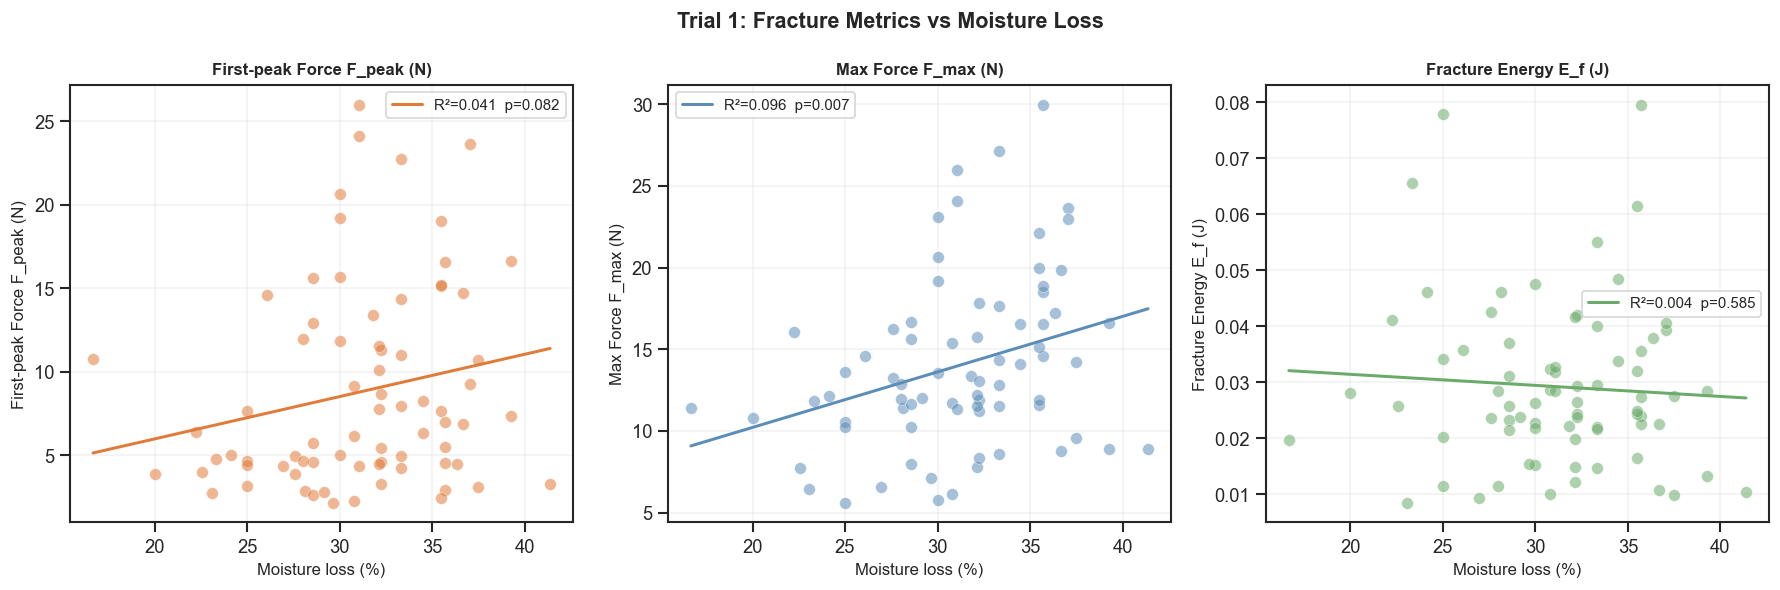

                     Metric  n    Mean     SD CV (%)    R²   slope p-value
First-peak Force F_peak (N) 74  8.8086 5.9600   67.7 0.041  0.2534  0.0823
        Max Force F_max (N) 74 14.0218 5.2470   37.4 0.096  0.3398  0.0072
    Fracture Energy E_f (J) 74  0.0292 0.0146   50.1 0.004 -0.0002  0.5849


In [120]:
metrics = [
    ('PeakForce_N',       'First-peak Force F_peak (N)',  '#e07b39'),
    ('MaxForce_N',        'Max Force F_max (N)',           '#5b8db8'),
    ('FractureEnergy_J',  'Fracture Energy E_f (J)',       '#6aab6a'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trial 1: Fracture Metrics vs Moisture Loss', fontsize=13, fontweight='bold')

summary_rows = []
for ax, (col, label, color) in zip(axes, metrics):
    x = df['Moisture_loss_pct'].values
    y = df[col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    r2 = r**2
    cv = y.std() / y.mean() * 100

    ax.scatter(x, y, color=color, alpha=0.55, edgecolors='white', linewidth=0.4, s=50)
    xfit = np.linspace(x.min(), x.max(), 200)
    ax.plot(xfit, slope * xfit + intercept, color=color, linewidth=1.8, label=f'R²={r2:.3f}  p={p:.3f}')
    ax.set_xlabel('Moisture loss (%)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

    summary_rows.append({'Metric': label, 'n': len(y), 'Mean': f"{y.mean():.4f}", 'SD': f"{y.std():.4f}",
                          'CV (%)': f"{cv:.1f}", 'R²': f"{r2:.3f}", 'slope': f"{slope:.4f}", 'p-value': f"{p:.4f}"})

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

#### 2.2 Regression results and quality comparison

The table above summarises the signal quality for each fracture metric. All three metrics show **poor predictability from moisture loss**, with large scatter throughout:

| Metric | CoV | Interpretation |
|---|---|---|
| **F_peak** | ~68 % | Worst. First-peak force is dominated by puffing geometry — the punch collapses a bubble rather than fracturing the chip matrix. The large spread reflects chip-to-chip puffing variation, not material differences. |
| **E_f** (fracture energy) | ~50 % | Intermediate. Integrating the force–displacement curve partially averages out the noisy onset, but the irregular loading path from puffed chips still inflates variability. |
| **F_max** | ~38 % | Least bad. Maximum force captures the highest load regardless of when it occurs, so it is less sensitive to the erratic first peak. Still highly variable by engineering standards. |

A Coefficient of Variation below ~15 % would typically indicate a reliable measurement. All three metrics here are well above that threshold, meaning no metric produces trustworthy fracture data in Trial 1.

#### 2.3 Why the results are poor

Beyond puffing, several other factors contribute to the scatter:

1. Chip geometry variability: Hand-cut or 3D-printed chips vary in thickness and diameter, altering the bending stiffness and fracture path.
2. Within-group moisture spread: As shown in Part 1, chips baked for the same duration span a wide moisture range (~±5–8 pp), so nominally identical specimens differ materially.
3. Contact mechanics: An uneven chip surface produces non-uniform stress concentration under the punch, making the fracture initiation point unpredictable.
4. Fracture mode inconsistency: Some chips fracture catastrophically in a single event; others show multiple partial cracks. These different modes produce fundamentally incomparable force–displacement profiles.

#### 2.4 Improvements for Trial 2.

The dominant failure mode, chip puffing, is a process-control problem rather than an inherent limitation of the measurement method. For Trial 2, the baking protocol was revised to reduce puffing by pressing chips down during puffing. This should bring F_peak back into contact with the chip matrix and reduce the CV of all three metrics to a range where regression against moisture loss becomes meaningful.